In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# Data Loading

In [ ]:
df=pd.read_csv("data/insurance.csv")


# EDA

In [72]:
df.head()
df.info()
df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1340 non-null   int64  
 1   sex       1340 non-null   object 
 2   bmi       1340 non-null   float64
 3   children  1340 non-null   int64  
 4   smoker    1340 non-null   object 
 5   region    1340 non-null   object 
 6   charges   1340 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.4+ KB


,age,sex,bmi,children,smoker,region,charges
1335,50,male,30.97,3,no,northwest,10600.5483
1336,18,female,31.92,0,no,northeast,2205.9808
1337,18,female,36.85,0,no,southeast,1629.8335
1338,21,female,25.80,0,no,southwest,2007.9450
1339,61,female,29.07,0,yes,northwest,29141.3603


In [73]:
df.describe()  #results numerical columns only

,age,bmi,children,charges
count,1340.000000,1340.000000,1340.000000,1340.000000
mean,39.185821,30.664384,1.094030,13254.789103
std,14.052785,6.094417,1.204966,12107.793341
min,18.000000,15.960000,0.000000,1121.873900
25%,26.750000,26.308750,0.000000,4719.683425
50%,39.000000,30.400000,1.000000,9369.615750
75%,51.000000,34.681250,2.000000,16604.302645
max,64.000000,53.130000,5.000000,63770.428010


In [74]:
df.isnull()    #checks null if yes then true else false
df.isnull().sum()  #no null values in the dataset

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [75]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

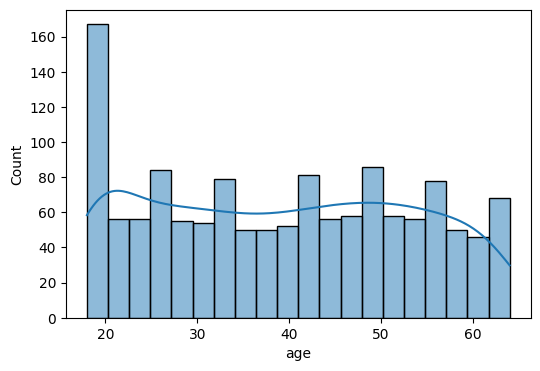

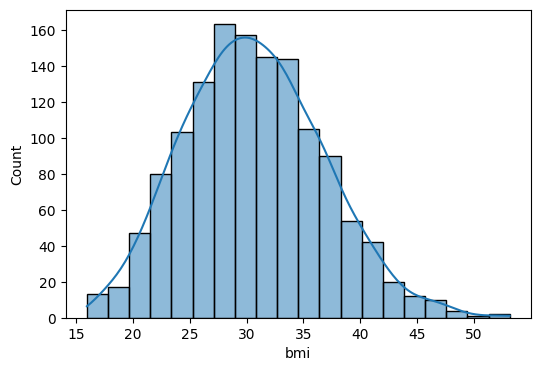

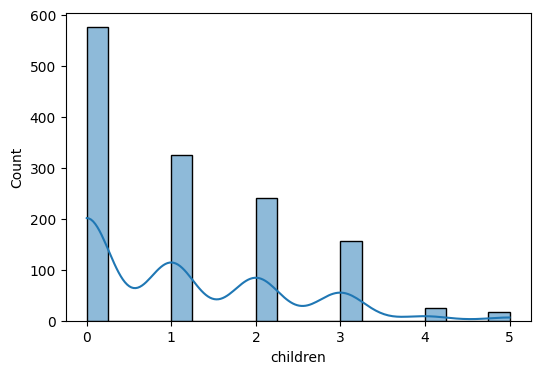

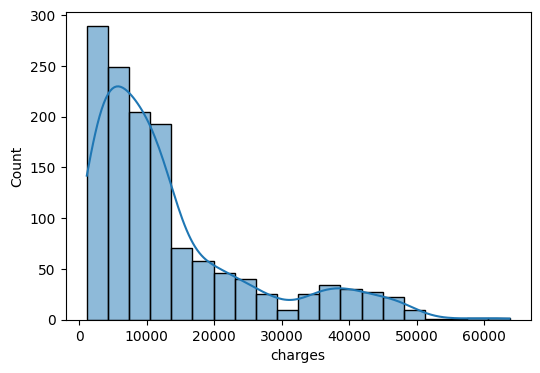

In [76]:
numeric_col=['age','bmi','children','charges']  #i want to  know distribution(normal) of these columns
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True,bins=20)  #kde is kernel density estimation it is used to plot the distribution of data
    # histogram gives best distribution plots

#for categorical columns

<Axes: xlabel='sex', ylabel='count'>

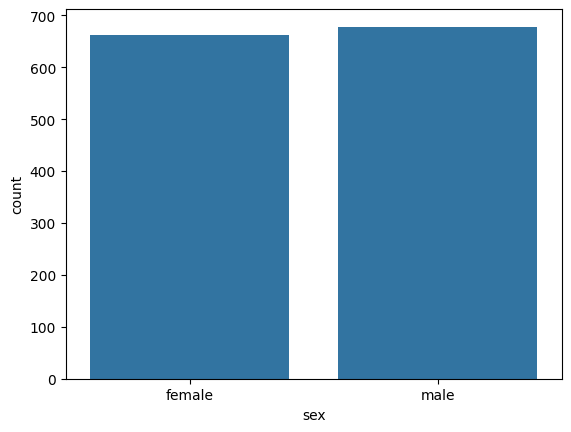

In [77]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

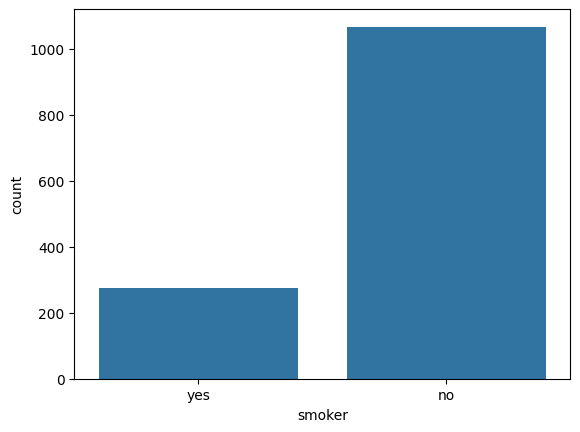

In [78]:
sns.countplot(x=df['smoker'])

<Axes: xlabel='children', ylabel='count'>

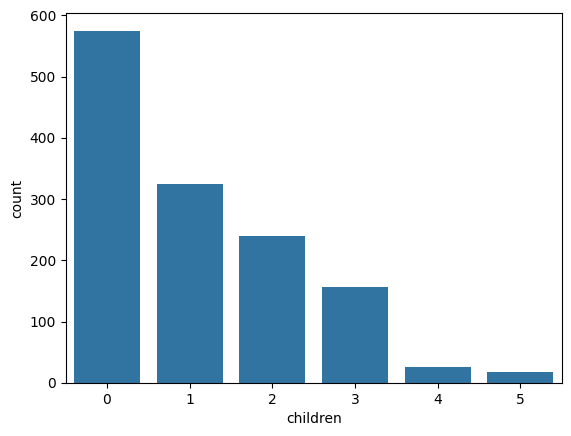

In [79]:
sns.countplot(x=df['children'])

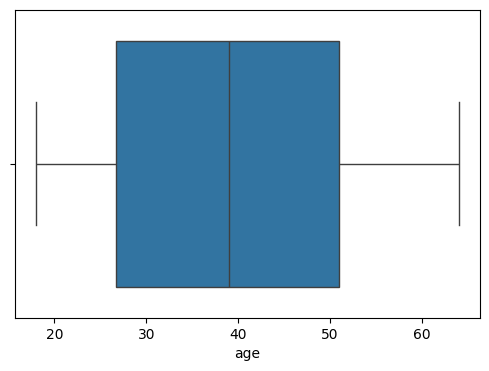

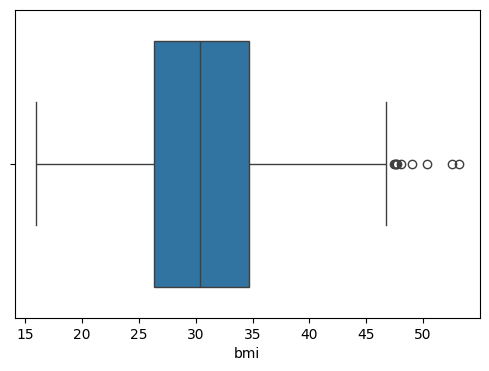

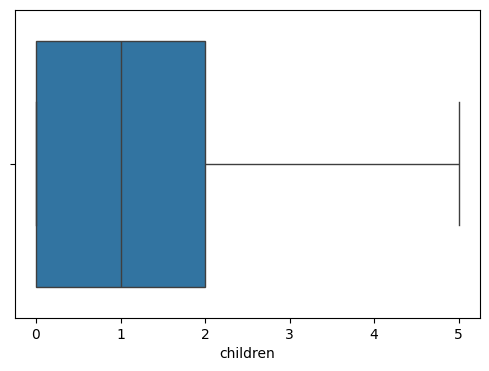

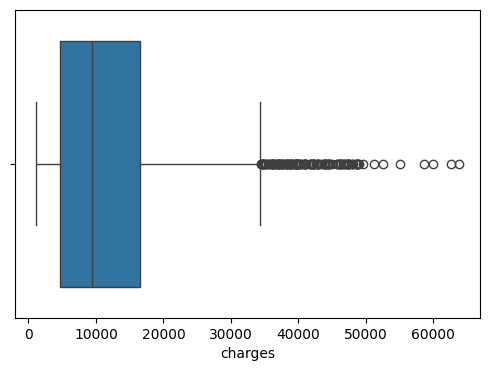

In [80]:
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

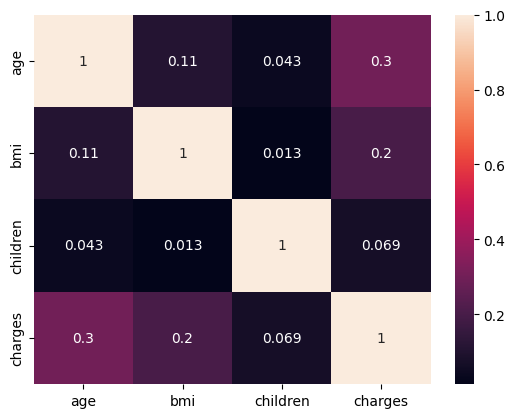

In [81]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

correlation tells the relation between columns
children is very less correlated -> so we can neglect children column

### Insights:
-  Smoking Impact : 
Smoking has the strongest effect on insurance charges, with smokers having significantly higher costs.
-  BMI and Age :
Higher BMI and age are positively correlated with increased insurance charges.
-  Model Behavior :
The model performs well overall but shows higher prediction errors for high-cost cases, indicating non-linear relationships.

# Data cleaning and preprocessing

In [82]:
df_cleaned=df.copy()
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,18,male,33.770,1,no,southeast,1725.55230


In [83]:
df_cleaned.shape

(1340, 7)

In [84]:
df_cleaned.drop_duplicates(inplace=True)

In [85]:
df_cleaned.shape

(1337, 7)

In [86]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [87]:
df_cleaned.dtypes  #for ml model all should be in numerical form so we have to convert categorical columns into numerical form

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [88]:
df_cleaned['sex'].value_counts()  #convert categorial to numerical using label encoding

sex
male      675
female    662
Name: count, dtype: int64

In [89]:
df_cleaned['sex']=df_cleaned['sex'].map({"female":1,"male":0})

In [90]:
df_cleaned['smoker'].value_counts()


smoker
no     1063
yes     274
Name: count, dtype: int64

In [91]:
df_cleaned['smoker']=df_cleaned['smoker'].map({"no": 0,"yes": 1})

In [92]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
5,32,0,28.880,0,0,northwest,3866.85520


In [93]:
df_cleaned.rename(columns={
    'sex':'isfemale',
    'smoker':'issmoker'
},inplace=True)

In [94]:
df_cleaned.head()

,age,isfemale,bmi,children,issmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
5,32,0,28.880,0,0,northwest,3866.85520


In [95]:
df['region'].value_counts()

region
southeast    365
northwest    326
southwest    325
northeast    324
Name: count, dtype: int64

In [96]:
#create dummy variables for region column
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [97]:
df_cleaned.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
5,32,0,28.880,0,0,3866.85520,True,False,False


In [98]:
df_cleaned=df_cleaned.astype(int)  #applies to entire table that is all boolean values in table will be converted to 0 and 1

In [99]:
df_cleaned

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
5,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1335,50,0,30,3,0,10600,1,0,0
1336,18,1,31,0,0,2205,0,0,0
1337,18,1,36,0,0,1629,0,1,0
1338,21,1,25,0,0,2007,0,0,1


# Feature engineering and Extraction

#####  *you can add new columns or discard columns to improve your model

<Axes: xlabel='bmi', ylabel='Count'>

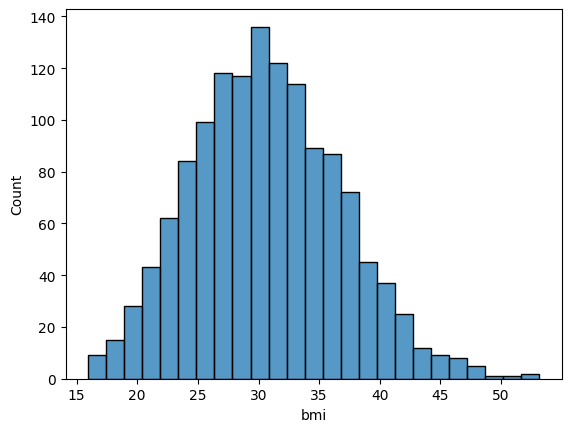

In [100]:
sns.histplot(x=df['bmi'])  
# bmi category => (0-18.5) underweight, (18.5-24.9) normal weight, (25-29.9) overweight, (30 and above) obese
# bins =>it is used to divide the data into intervals or groups.  


In [101]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],bins=[0,18.5,24.5,29.5,float('inf')],
    labels=['underweight','normalweight','overweight','obese']
                                  )

In [102]:
df_cleaned.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normalweight
5,32,0,28,0,0,3866,1,0,0,overweight


In [103]:
df_cleaned['bmi_category'].value_counts()

bmi_category
obese           706
overweight      386
normalweight    221
underweight      24
Name: count, dtype: int64

In [104]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'])

In [105]:
df_cleaned

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normalweight,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,False,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,False,True
3,33,0,22,0,0,21984,1,0,0,False,True,False,False
5,32,0,28,0,0,3866,1,0,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,50,0,30,3,0,10600,1,0,0,False,False,False,True
1336,18,1,31,0,0,2205,0,0,0,False,False,False,True
1337,18,1,36,0,0,1629,0,1,0,False,False,False,True
1338,21,1,25,0,0,2007,0,0,1,False,False,True,False


In [106]:
df_cleaned=df_cleaned.astype(int)

In [107]:
df_cleaned.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normalweight,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,0,1,0,0
5,32,0,28,0,0,3866,1,0,0,0,0,1,0


# Feature scaling

##### all input features (columns) to a similar scale 
(Normalisation (0,1), Standardization(u=0,s=1))

In [108]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()

df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])  # (-3,3)

In [109]:
df_cleaned.head()

,age,isfemale,bmi,children,issmoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normalweight,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,0,1,0,0
5,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,0,1,0


# Feature extraction

In [110]:
df_cleaned.columns

Index(['age', 'isfemale', 'bmi', 'children', 'issmoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_underweight', 'bmi_category_normalweight',
       'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [111]:
# we have scaled down everything , now i want to check the corelation of targeted feature (charges feature) with other features

# for that i will use "pearson correlation" coefficient which is a measure of the linear correlation between two variables. It ranges from -1 to 1,
#  where -1 indicates a perfect negative correlation, 0 indicates no correlation, and 1 indicates a perfect positive correlation.

# r,p_value=pearsonr(x,y)  ,  r= strong + direction  , p_value < 0.05 means there is a significant correlation between x and y

from scipy.stats import pearsonr

features=['age', 'isfemale', 'bmi', 'children', 'issmoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_underweight', 'bmi_category_normalweight',
       'bmi_category_overweight', 'bmi_category_obese']

correlation={
    features: pearsonr(df_cleaned[features],df_cleaned['charges'])[0]
    for features in features
}

correlation_df=pd.DataFrame(list(correlation.items()),columns=['Features','Pearson correlation'])
correlation_df.sort_values(by='Pearson correlation',ascending=False)


,Features,Pearson correlation
4,issmoker,0.787234
0,age,0.298309
11,bmi_category_obese,0.200348
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
8,bmi_category_underweight,-0.050599
1,isfemale,-0.058046


In [112]:
# -1       0          1
# if correlation is more than 0.5 then it is a strong positive correlation => u can use this feature for prediction 

In [113]:
# the correlation less than 0 are mostly categorial , so lets check chi square test for cateogorial features
# but "charges" is a numerical features so we will use "bins" to convert it into categorial features

from scipy.stats import chi2_contingency
import pandas as pd

cat_features=[ 'isfemale', 'issmoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_underweight', 'bmi_category_normalweight',
       'bmi_category_overweight', 'bmi_category_obese']
alpha=0.05

df_cleaned['charges_bins']=pd.qcut(df_cleaned['charges'],q=4) 
chi2_results={}

for col in cat_features:
    contigency=pd.crosstab(df_cleaned[col],df_cleaned['charges_bins'])
    chi2_stat,p_val,_,_=chi2_contingency(contigency)
    decision='Reject null(keep feature)' if p_val < alpha else 'Accept null(drop_feature)'

    chi2_results[col]={
        'chi2_statistic ':chi2_stat,
        'p_value': p_val,
        'decision':decision

    }

chi_df=pd.DataFrame(chi2_results).T
chi_df=chi_df.sort_values(by='p_value',ascending=True)
chi_df

,chi2_statistic,p_value,decision
issmoker,848.219178,0.0,Reject null(keep feature)
region_southeast,15.998167,0.001135,Reject null(keep feature)
isfemale,10.258784,0.01649,Reject null(keep feature)
bmi_category_obese,8.515711,0.036473,Reject null(keep feature)
region_southwest,5.091893,0.165191,Accept null(drop_feature)
bmi_category_overweight,4.25149,0.235557,Accept null(drop_feature)
bmi_category_normalweight,3.708088,0.29476,Accept null(drop_feature)
bmi_category_underweight,3.37403,0.337471,Accept null(drop_feature)
region_northwest,1.13424,0.768815,Accept null(drop_feature)


In [114]:
final_df=df_cleaned[['age','bmi','children','charges','issmoker','isfemale','region_southeast','bmi_category_obese']]
final_df

,age,bmi,children,charges,issmoker,isfemale,region_southeast,bmi_category_obese
0,-1.440418,-0.517949,-0.909234,16884,1,1,0,0
1,-1.511647,0.462463,-0.079442,1725,0,0,1,1
2,-0.799350,0.462463,1.580143,4449,0,0,1,1
3,-0.443201,-1.334960,-0.909234,21984,0,0,0,0
5,-0.514431,-0.354547,-0.909234,3866,0,0,0,0
...,...,...,...,...,...,...,...,...
1335,0.767704,-0.027743,1.580143,10600,0,0,0,1
1336,-1.511647,0.135659,-0.909234,2205,0,1,0,1
1337,-1.511647,0.952670,-0.909234,1629,0,1,1,1
1338,-1.297958,-0.844753,-0.909234,2007,0,1,0,0


# Model Training

In [115]:
X = final_df.drop('charges', axis=1)
y = final_df['charges']

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Model Prediction

In [117]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Model Evaluation

In [118]:
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

Linear Regression Results:
MAE: 4295.197838389794
MSE: 36003101.65243352
R2 Score: 0.8040712413347118


In [119]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [120]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results:
MAE: 3399.3333333333335
MSE: 47003271.79456882
R2 Score: 0.7442083522463807


In [121]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.8670425333395345


### Model comparision

In [122]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2 Score": [r2, r2_dt, r2_score(y_test, y_pred_rf)]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.804071
1      Decision Tree  0.744208
2      Random Forest  0.867043


# Visualization

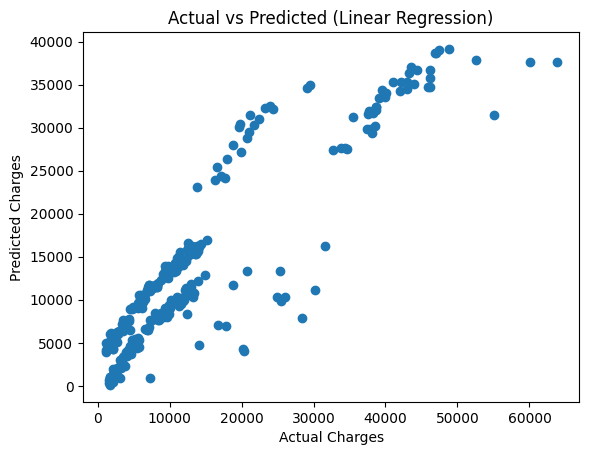

In [123]:
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

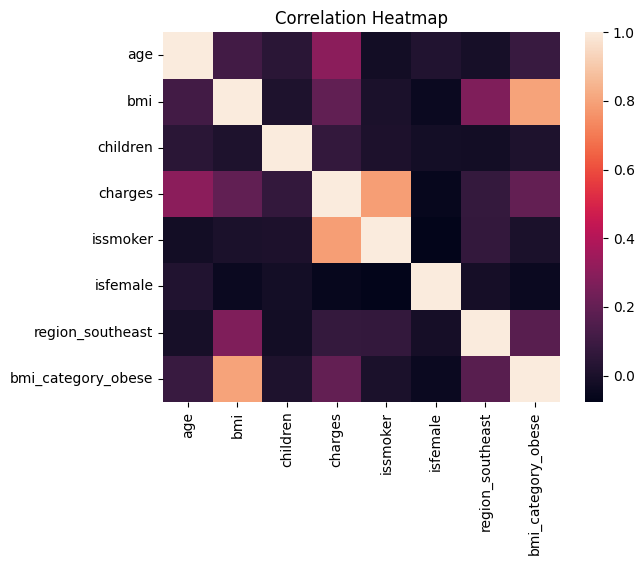

In [124]:
plt.figure()
sns.heatmap(final_df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Conclusion

- Linear Regression achieved the best performance with R² score of 0.80  
- Decision Tree showed lower performance due to overfitting  
- Random Forest improved prediction accuracy further  
- Smoking status and BMI are the most important factors affecting insurance charges  

This project demonstrates a complete machine learning pipeline from data preprocessing to model evaluation.